In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact

In [23]:
# function definitions
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid huge memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

In [24]:
# load the ANYI pickle file
DATA_DIR     = "../../flatten/processed-data"
DATA_FILE    = f"{DATA_DIR}/20251209-s288c-annotated-PPI-net.pkl"
nodes        = pd.read_pickle(DATA_FILE)

In [25]:
# determine threshold for hubs based on quantile cutoff for degree centrality
cut          = 0.10
threshold    = nodes["degree_centrality"].quantile(1 - cut)

# add a boolean hub column: True if degree_centrality >= threshold, else False
nodes["hub"] = nodes["degree_centrality"] >= threshold

In [11]:
# check if there is a gold quality level PTM for each protein
has_phospho_flag = (nodes["ptm_gold"].notna())

# check if there is UniProt entry text indicating phosphorylation
has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)

# combine both criteria
nodes["phosphorylated"] = has_phospho_flag | has_phospho_text

This is our contingency table:



<Figure size 640x480 with 0 Axes>

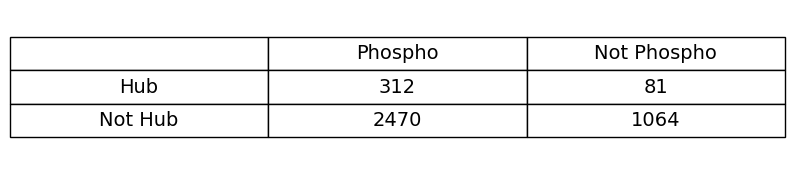

The odds ratio is: 1.66
The p-value is   : 0.0000660


In [12]:
# compute the values of {a, b, c, d} and construct the contingency table
a = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == True )])
b = len(nodes[(nodes["hub"] == True ) & (nodes["phosphorylated"] == False)])
c = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == True )])
d = len(nodes[(nodes["hub"] == False) & (nodes["phosphorylated"] == False)])

# put values into a new format to enable a nice print statement & analysis
contingency_table = pd.DataFrame({"Phospho"    : [a, c], 
                                  "Not Phospho": [b, d]},
                                  index = ["Hub", "Not Hub"])

# print the output
print ("This is our contingency table:\n")

# create a table from our contingency_table using matplotlib
plt.clf()
fig, ax    = plt.subplots(figsize = (5, 2))
ax.axis("tight")
ax.axis("off")
cell_text  = contingency_table.reset_index().values.tolist()
col_labels = [""] + contingency_table.columns.tolist()
table      = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(14)  
table.scale(2, 2)  
plt.show()

# use the fisher_exact function from scipy.stats to compute the odds ratio and p-value
odds_ratio, fisher_p_value = fisher_exact(contingency_table, alternative = "two-sided")

# print the results of this analysis
print ("The odds ratio is:", "%.2f" %odds_ratio)
print ("The p-value is   :", "%.7f" %fisher_p_value)

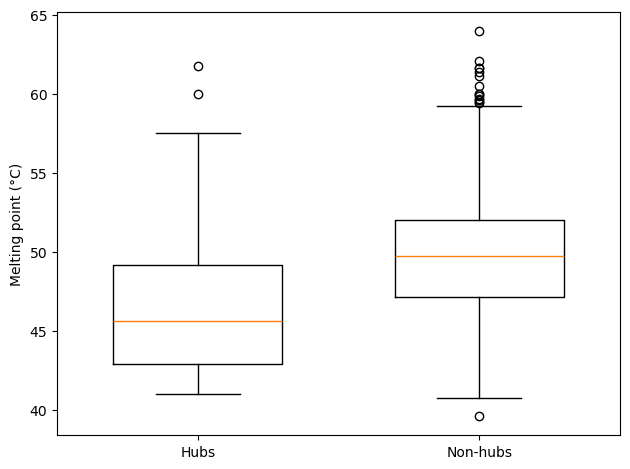

In [20]:
subset = nodes[nodes["meltome-fit-R2"] >= 0.9].copy()

hub_tm = subset.loc[subset["hub"], "meltome-melting-point"].dropna()
nonhub_tm = subset.loc[~subset["hub"], "meltome-melting-point"].dropna()

plt.clf()
plt.boxplot(
    [hub_tm, nonhub_tm],
    positions=[1, 2],     
    widths=0.6,            
)

plt.xticks([1, 2], ["Hubs", "Non-hubs"])
plt.ylabel("Melting point (°C)")   
plt.tight_layout()

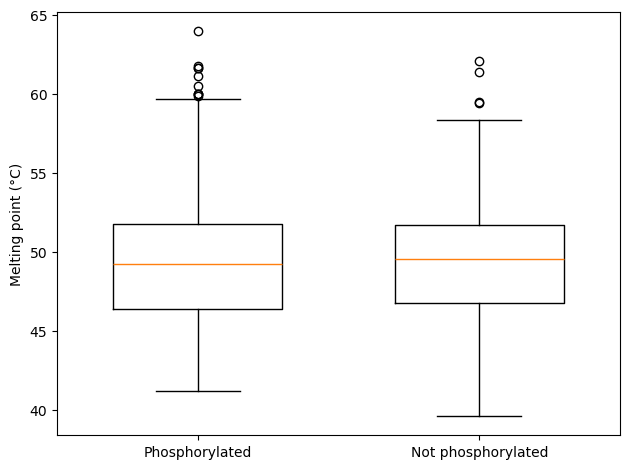

In [22]:
subset = nodes[nodes["meltome-fit-R2"] >= 0.9].copy()

hub_tm = subset.loc[subset["phosphorylated"], "meltome-melting-point"].dropna()
nonhub_tm = subset.loc[~subset["phosphorylated"], "meltome-melting-point"].dropna()

plt.clf()
plt.boxplot(
    [hub_tm, nonhub_tm],
    positions=[1, 2],      
    widths=0.6,            
)

plt.xticks([1, 2], ["Phosphorylated", "Not phosphorylated"])
plt.ylabel("Melting point (°C)")  
plt.tight_layout()

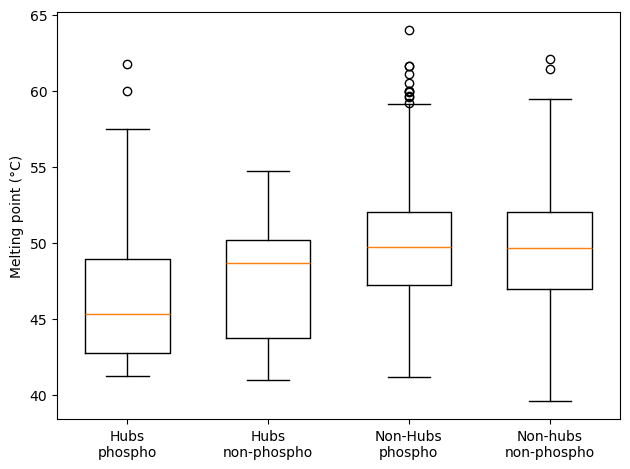

In [21]:
subset = nodes[nodes["meltome-fit-R2"] >= 0.9].copy()

hubs = subset[subset["hub"] == True]
nonhubs = subset[subset["hub"] != True]

hub_phos = hubs.loc[hubs["phosphorylated"], "meltome-melting-point"].dropna()
hub_nonphos = hubs.loc[~hubs["phosphorylated"], "meltome-melting-point"].dropna()
nonhub_phos = nonhubs.loc[nonhubs["phosphorylated"], "meltome-melting-point"].dropna()
nonhub_nonphos = nonhubs.loc[~nonhubs["phosphorylated"], "meltome-melting-point"].dropna()

plt.clf()
plt.boxplot(
    [hub_phos, hub_nonphos, nonhub_phos, nonhub_nonphos],
    positions=[1, 2, 3, 4],
    widths=0.6,
)

plt.xticks([1, 2, 3, 4], ["Hubs\nphospho", "Hubs\nnon-phospho", "Non-Hubs\nphospho", "Non-hubs\nnon-phospho"])
plt.ylabel("Melting point (°C)")
plt.tight_layout()